# Medium Project 🟡 - Predicting Car Efficiency (mpg) with a Decision Tree

> **MLCourse · Machine Learning · supervised · regression**

## What you'll learn

1. Real-world cleaning: **median-imputing** missing horsepower and one-hot
   encoding a categorical (`origin`).
2. Tuning tree depth with cross-validation instead of guesswork.
3. Reading feature importances - expect `weight` and `displacement` on top.
4. Seeing the tree's **staircase fingerprint** in the residual plot.

In [1]:
# Setup cell: libraries, reproducibility, plot styling (run me first).
try:  # inline plots inside Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # equivalent of the %matplotlib magic
except NameError:  # plain script mode → nothing to configure
    pass

import numpy as np                  # vector maths
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # figures
import seaborn as sns               # statistical graphics

from sklearn.model_selection import train_test_split, cross_val_score   # split + honest scoring
from sklearn.tree import DecisionTreeRegressor                          # this chapter's model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)                  # reproducible randomness
sns.set_theme()                     # clean default styling
plt.rcParams["figure.dpi"] = 100    # light crisp plots

## 1. Business question

> *An auto consultancy wants a quick rule-of-thumb estimator: given an
> engine's physical specs, what city MPG should we expect? A shallow tree
> gives both the estimate AND the thresholds engineers argue about.*

Dataset: the classic `mpg` table - 398 cars, mix of numeric specs and one
categorical (`origin`), with a handful of missing `horsepower` entries.

In [2]:
from pathlib import Path  # portable filesystem paths

def find_data_dir():
    # Climb from the current folder up to the course's '02_machine_learning' directory,
    # then use its shared 'data' sub-folder.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # step up one directory each loop
    return here / "data"

DATA_DIR = find_data_dir()          # canonical data location for every notebook

def load_mpg():
    # Download-once helper: reuse local cache, else fetch from the seaborn mirror.
    csv_path = DATA_DIR / "mpg.csv"
    if not csv_path.exists():       # first run downloads
        import urllib.request       # stdlib downloader
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv",
            csv_path,
        )
        print(f"Downloaded -> {csv_path}")
    return pd.read_csv(csv_path)

mpg = load_mpg()
print(mpg.shape)
mpg.head()

(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### Missing audit → justified imputation

`horsepower` has 6 NaNs. The column is right-skewed (a few muscle cars),
so the **median** is the safer fill: means get dragged by that tail.
💡 We add a `horsepower_missing` flag so the tree can even learn from the
fact that a value was absent.

In [3]:
print("missing per column:")                    # explicit null audit
print(mpg.isna().sum()[lambda s: s > 0])        # show only columns that actually have NaNs

hp_median = mpg["horsepower"].median()          # robust central value for skewed distributions
mpg["horsepower"] = mpg["horsepower"].fillna(hp_median)      # median-fill (skew-safe)
print(f"filled horsepower NaNs with median = {hp_median}")   # document the imputation choice

print(f"\nfilled horsepower NaNs with median = {hp_median}")

missing per column:
horsepower    6
dtype: int64
filled horsepower NaNs with median = 93.5

filled horsepower NaNs with median = 93.5


### EDA: target, relationships, correlation panel

MPG falls as weight/displacement/horsepower rise - strong monotone but
clearly **non-linear** (curved clouds), which is exactly where trees shine.

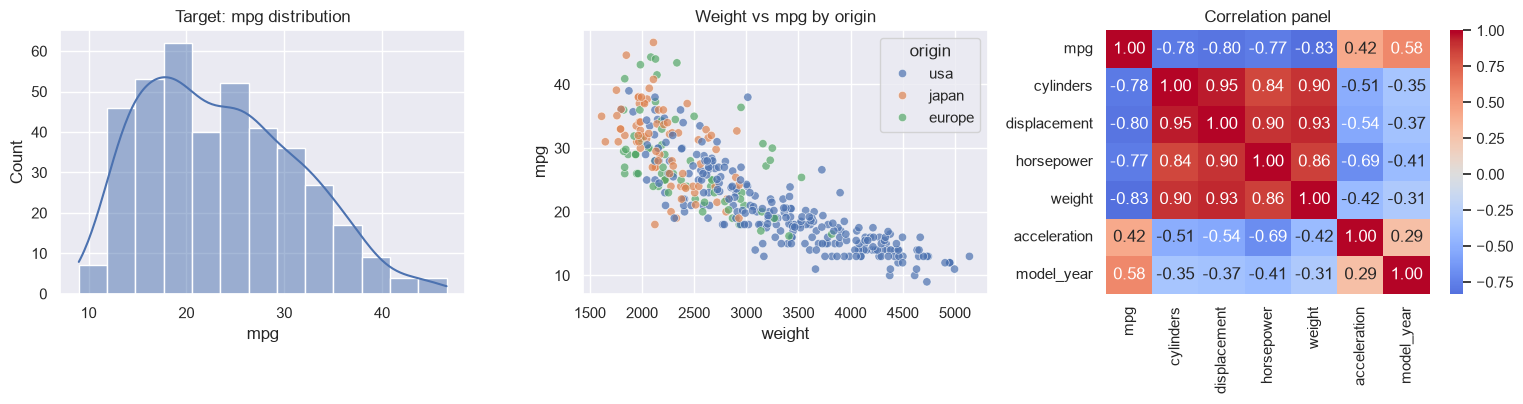

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))
sns.histplot(mpg["mpg"], kde=True, ax=axes[0])                    # target distribution: mild right skew
axes[0].set_title("Target: mpg distribution")
sns.scatterplot(data=mpg, x="weight", y="mpg", hue="origin",
                alpha=0.7, ax=axes[1])                            # strongest single relationship
axes[1].set_title("Weight vs mpg by origin")
num_cols = ["mpg", "cylinders", "displacement", "horsepower",
            "weight", "acceleration", "model_year"]
sns.heatmap(mpg[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[2])                # linear-correlation orientation
axes[2].set_title("Correlation panel")
plt.tight_layout()
plt.show()

## 2. Processing: encode + split

One-hot `origin` into dummy columns (drop-first avoids redundancy). `name`
is an ID-like string - dropped. Then hold out 20% for final honesty.

In [5]:
mpg_enc = pd.get_dummies(
    mpg.drop(columns=["name"]),                 # name is an identifier, not a predictor
    columns=["origin"],                         # categoricals must become numbers
    drop_first=True,                            # k-1 dummies to avoid the dummy trap
)
features = [c for c in mpg_enc.columns if c != "mpg"]   # everything except the target
X, y = mpg_enc[features], mpg_enc["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,               # fixed seed → identical split for everyone
)
print(f"features ({len(features)}): {features}")
print(f"train {X_train.shape} | test {X_test.shape}")

features (8): ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']
train (318, 8) | test (80, 8)


## 3. Depth tuning via 5-fold CV

Audition depths 1-12 on the training partition only. Shallow depths underfit
(can't capture the curved weight→mpg relationship); unbounded depth starts
memorising noise. Pick the CV peak, then evaluate once on test.

best max_depth by CV: 5  (CV R²=0.790)


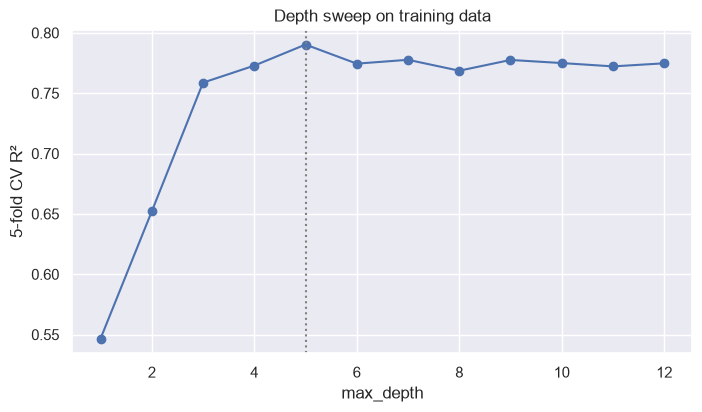

In [6]:
depths = list(range(1, 13))                          # candidate depths
cv_means = []
for d in depths:                                     # honest audition per depth
    dt = DecisionTreeRegressor(max_depth=d, random_state=42)
    cv_means.append(cross_val_score(dt, X_train, y_train, cv=5,
                                    scoring="r2").mean())   # mean of five fold R²s
best_depth = depths[int(np.argmax(cv_means))]        # CV winner
print(f"best max_depth by CV: {best_depth}  (CV R²={max(cv_means):.3f})")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(depths, cv_means, "o-")
ax.axvline(best_depth, ls=":", c="gray")             # highlight the optimum
ax.set(xlabel="max_depth", ylabel="5-fold CV R²", title="Depth sweep on training data")
plt.show()

tree_best = DecisionTreeRegressor(max_depth=best_depth, random_state=42).fit(X_train, y_train)

## 4. Evaluation table + feature importances

Compare against the naive mean baseline, then inspect where the tree spends
its splits. ⚠️ Impurity-based importances are hints, not causal truths.

baseline (train mean)      MAE=  5.96  RMSE=  7.35  R²=-0.004
tree depth=5               MAE=  2.28  RMSE=  3.30  R²= 0.797


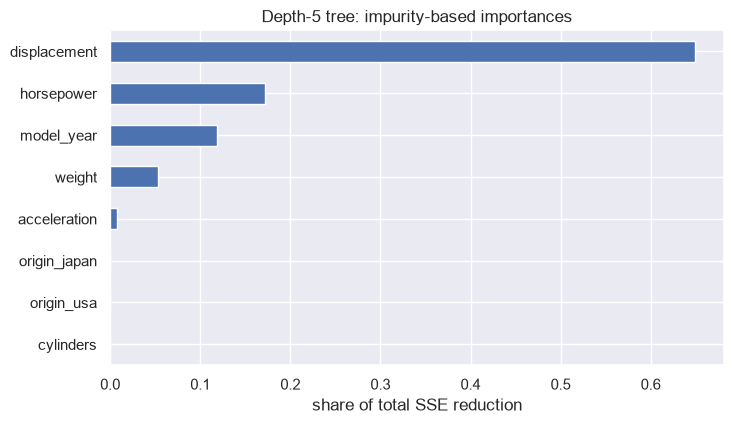

,model,MAE,RMSE,R2
0,baseline (train mean),5.955409,7.347333,-0.004033
1,tree depth=5,2.284156,3.303446,0.797034


In [7]:
def regression_report(y_true, y_pred, label):
    """One standardised metrics row: MAE / RMSE / R²."""
    mae = mean_absolute_error(y_true, y_pred)                   # typical miss in MPG points
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))          # outlier-sensitive miss
    r2 = r2_score(y_true, y_pred)                               # variance explained vs mean
    print(f"{label:<26} MAE={mae:6.2f}  RMSE={rmse:6.2f}  R²={r2:6.3f}")
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = [
    regression_report(y_test, np.full(len(y_test), y_train.mean()), "baseline (train mean)"),
    regression_report(y_test, tree_best.predict(X_test), f"tree depth={best_depth}"),
]

imp = pd.Series(tree_best.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 4.4))
imp.plot.barh(ax=ax)                                 # importance shares per feature
ax.set_title(f"Depth-{best_depth} tree: impurity-based importances")
ax.set_xlabel("share of total SSE reduction")
plt.tight_layout(); plt.show()
pd.DataFrame(results)

## 5. Residuals reveal the staircase

Plot residuals (actual − predicted) against fitted values. Because a tree
outputs only a handful of distinct values (one per leaf), predictions stack
into vertical **bands** - the visual fingerprint of piecewise-constant models.

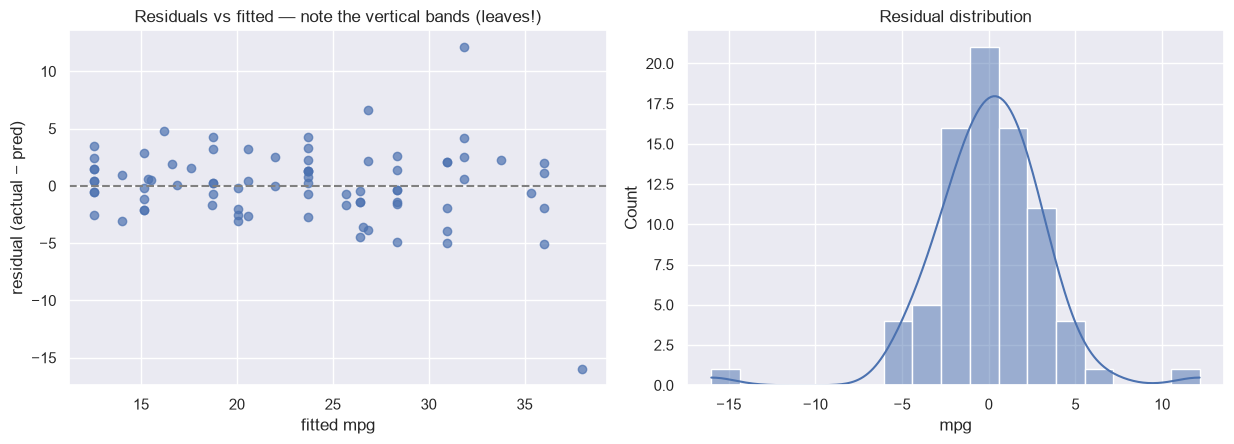

distinct leaf outputs used on test: 26 (tree has 29 leaves)


In [8]:
pred_test = tree_best.predict(X_test)
resid_test = y_test - pred_test                      # positive = model under-predicted

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].scatter(pred_test, resid_test, alpha=0.7)
axes[0].axhline(0, ls="--", c="gray")                # perfect-prediction line
axes[0].set(xlabel="fitted mpg", ylabel="residual (actual − pred)",
            title=f"Residuals vs fitted - note the vertical bands (leaves!)")
sns.histplot(resid_test, kde=True, ax=axes[1])       # residual spread shape
axes[1].set_title("Residual distribution")
plt.tight_layout(); plt.show()

print(f"distinct leaf outputs used on test: {np.unique(pred_test).size} "
      f"(tree has {tree_best.get_n_leaves()} leaves)")

## Findings

1. **Weight dominates** (largest importance share), with displacement and
   horsepower next - engine bulk is the efficiency story of this era.
2. **CV picks a moderate depth (~4-5).** Shallower can't bend with the curved
   weight relationship; deeper starts fitting noise and CV R² stalls/declines.
3. **Solid lift over baseline:** test MAE roughly halves versus predicting the
   mean; R² lands around ~0.75-0.8 depending on the split draw.
4. **The staircase is visible:** residual-vs-fitted shows vertical bands -
   every car in the same leaf gets the same number, by construction.

## Limitations

- Steps are physically implausible at edges (a 10 lb weight change can flip a leaf).
- `model_year` leaks era effects: newer cars are simply more efficient; the
  tree uses it as a proxy for technology rather than physics.
- No extrapolation: ask about a 9,000 lb vehicle and the tree repeats its
  heaviest leaf's average - flat nonsense outside the training range.